#  Flood Segmentation — YOLO Backbone + UNet++ Decoder | Phase 2 (3-Class)

**Classes:** 0 No-Flood · 1 Flood · 2 Water-Body  
**Backbone:** YOLOv8-small CSPDarknet (pretrained on COCO, adapted for 6-channel input)  
**Pipeline:** 512×512 TIFs → 256x256 overlapping patches → YOLO encoder + UNet++ decoder → stitch → dynamic threshold → RLE  


## 0 · Environment & Imports

In [ ]:
import subprocess, sys
pkgs = ["ultralytics>=8.2.0"]   # brings in YOLOv8 + its backbone weights
for p in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

# Silence ultralytics' noisy startup logging
import ultralytics
ultralytics.checks()
print("ultralytics", ultralytics.__version__, "ready ✓")


In [ ]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [1]:
import os, warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")

# ── standard ──────────────────────────────────────────────────────────────
import os, glob, re, csv, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ── geo ────────────────────────────────────────────────────────────────────
import rasterio
import cv2

# ── torch ─────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch :', torch.__version__)
print('Device  :', DEVICE)
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))
    print('VRAM    :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), 'GB')


PyTorch : 2.7.1+cu118
Device  : cuda
GPU     : Tesla P100-PCIE-16GB
VRAM    : 17.06 GB


## 1 · Configuration

In [27]:
CFG = dict(
    # ── Paths ──────────────────────────────────────────────────────────────
    DATA_ROOT       = Path('/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data'),
    IMAGE_DIR       = Path('/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/image'),
    LABEL_DIR       = Path('/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/label'),
    PRED_IMAGE_DIR  = Path('/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/prediction/image'),
    SPLIT_DIR       = Path('/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/split'),
    CKPT_DIR        = Path('/kaggle/working/checkpoints'),
    VIZ_DIR         = Path('/kaggle/working/viz'),
    SUB_CSV         = Path('/kaggle/working/submission.csv'),
    PRED_SPLIT_FILE = Path('/kaggle/input/competitions/anrfaisehack-theme-1-phase2/data/split/pred.txt'),

    # ── Data ───────────────────────────────────────────────────────────────
    FULL_SIZE       = 512,
    PATCH_SIZE      = 256,   # YOLOv8 default input size
    STRIDE          = 192,   # 160 px overlap
    N_CHANNELS      = 6,     # HH HV Green Red NIR SWIR
    NUM_CLASSES     = 3,

    # ── Class weights (No-Flood dominant → down-weight it) ─────────────────
    CLASS_WEIGHTS   = [0.0737, 0.6798, 0.2465],

    # ── YOLO backbone ──────────────────────────────────────────────────────
    YOLO_MODEL      = 'yolov8s.pt',   # small = good speed/accuracy trade-off
    #   Options: yolov8n.pt (nano, fastest), yolov8s.pt, yolov8m.pt, yolov8l.pt
    #   Larger = better features but more VRAM.
    FREEZE_STAGES   = 2,   # freeze first N CSP stages (0 = train all)

    # ── Decoder ────────────────────────────────────────────────────────────
    # YOLO-small backbone output channels per stage:
    #   stage2 (P3, 1/8):  128
    #   stage3 (P4, 1/16): 256
    #   stage4 (P5, 1/32): 512
    DECODER_CHANNELS = [256, 128, 64, 32],
    DROPOUT          = 0.1,

    # ── Training ───────────────────────────────────────────────────────────
    BATCH_SIZE      = 4,
    GRAD_ACCUM      = 4,    # effective batch = 16
    EPOCHS          = 20,
    LR              = 2e-4,
    BACKBONE_LR     = 1e-5,
    LR_MIN          = 1e-6,
    WEIGHT_DECAY    = 1e-4,
    SEED            = 42,
    AMP             = True,

    # ── Threshold search ───────────────────────────────────────────────────
    THRESH_STEPS    = 21,
)

CFG['CKPT_DIR'].mkdir(exist_ok=True)
CFG['VIZ_DIR'].mkdir(exist_ok=True)

random.seed(CFG['SEED'])
np.random.seed(CFG['SEED'])
torch.manual_seed(CFG['SEED'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG['SEED'])

NUM_CLASSES = CFG['NUM_CLASSES']
print('Config OK ✓')


Config OK ✓


## 2 · I/O Utilities

In [28]:
CH_MEAN = np.zeros(6, dtype=np.float32)
CH_STD  = np.ones(6,  dtype=np.float32)
CH_P1   = np.zeros(6, dtype=np.float32)
CH_P99  = np.ones(6,  dtype=np.float32)


def load_tif(path):
    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)   # (C, H, W)
    img = np.transpose(img, (1, 2, 0))         # (H, W, C)
    np.nan_to_num(img, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
    return img


def load_label(path):
    with rasterio.open(path) as src:
        lbl = src.read(1).astype(np.uint8)
    return lbl


def normalise(img, mean, std, p1, p99, eps=1e-6):
    img = img.copy()
    for c in range(img.shape[-1]):
        img[..., c] = np.clip(img[..., c], p1[c], p99[c])
    return (img - mean) / (std + eps)


def read_split(txt_path):
    with open(txt_path) as f:
        return [l.strip() for l in f if l.strip()]


print('I/O utilities defined ✓')


I/O utilities defined ✓


## 3 · Compute Channel Statistics

In [29]:
train_ids = read_split(CFG['SPLIT_DIR'] / 'train.txt')


def compute_channel_stats(split_ids, image_dir, sample_frac=0.5, seed=42):
    rng    = np.random.default_rng(seed)
    chosen = rng.choice(split_ids,
                        size=max(1, int(len(split_ids) * sample_frac)),
                        replace=False)
    all_px = [[] for _ in range(6)]
    for sid in chosen:
        p = image_dir / f'{sid}_image.tif'
        if not p.exists():
            continue
        img = load_tif(p)
        for c in range(6):
            flat = img[..., c].ravel()
            flat = flat[np.isfinite(flat)]
            if len(flat):
                all_px[c].append(flat)

    means, stds, p1s, p99s = [], [], [], []
    for c in range(6):
        arr = np.concatenate(all_px[c]) if all_px[c] else np.array([0.0])
        p1, p99  = np.percentile(arr, [1, 99])
        clipped  = np.clip(arr, p1, p99)
        means.append(clipped.mean())
        stds.append(clipped.std() + 1e-6)
        p1s.append(p1);  p99s.append(p99)
    return (np.array(means, np.float32), np.array(stds,  np.float32),
            np.array(p1s,   np.float32), np.array(p99s,  np.float32))


print('Computing channel stats on training set …')
CH_MEAN, CH_STD, CH_P1, CH_P99 = compute_channel_stats(
    train_ids, CFG['IMAGE_DIR'], sample_frac=0.5)

for i, n in enumerate(['HH','HV','Green','Red','NIR','SWIR']):
    print(f'  {n:6s}  mean={CH_MEAN[i]:8.4f}  std={CH_STD[i]:8.4f}'
          f'  p1={CH_P1[i]:8.4f}  p99={CH_P99[i]:8.4f}')
print('Stats OK ✓')


Computing channel stats on training set …
  HH      mean=803.0691  std=366.3742  p1=132.6442  p99=1772.1998
  HV      mean=367.0354  std=157.2911  p1= 81.7375  p99=747.8356
  Green   mean=1948.4420  std=581.9854  p1=843.1117  p99=3262.2339
  Red     mean=1800.7977  std=568.7239  p1=683.9394  p99=3007.8062
  NIR     mean=1923.8070  std=528.7676  p1=857.0852  p99=3143.9810
  SWIR    mean=1377.2235  std=475.6431  p1=384.9871  p99=2303.2178
Stats OK ✓


## 4 · Patch Extraction & Stitching

In [30]:
def get_patch_coords(full_size, patch_size, stride):
    coords = []
    for r in range(0, full_size - patch_size + 1, stride):
        for c in range(0, full_size - patch_size + 1, stride):
            coords.append((r, c))
    last  = full_size - patch_size
    extra = [(last, c) for _, c in coords if last not in [r for r,_ in coords]]
    extra += [(r, last) for r, _ in coords if last not in [c for _,c in coords]]
    extra.append((last, last))
    return list(dict.fromkeys(coords + extra))


def extract_patches(img, patch_size, stride):
    """img: (H, W, C) or (H, W).  Returns list of (patch, r, c)."""
    H, W = img.shape[:2]
    patches = []
    for r, c in get_patch_coords(H, patch_size, stride):
        p = img[r:r+patch_size, c:c+patch_size]
        if p.shape[:2] == (patch_size, patch_size):
            patches.append((p, r, c))
    return patches


def stitch_patches(patch_preds, full_size=512, patch_size=640, n_classes=3):
    """Average-blend overlapping softmax predictions back to full image."""
    acc   = np.zeros((full_size, full_size, n_classes), dtype=np.float64)
    count = np.zeros((full_size, full_size, 1),         dtype=np.float64)
    for pred, r, c in patch_preds:
        # pred may be larger than the canvas region — clip to canvas
        h = min(patch_size, full_size - r)
        w = min(patch_size, full_size - c)
        acc  [r:r+h, c:c+w] += pred[:h, :w]
        count[r:r+h, c:c+w] += 1
    return (acc / np.maximum(count, 1)).astype(np.float32)


print('Patch utilities defined ✓')
print(f'  Patches per image: {len(get_patch_coords(512, CFG["PATCH_SIZE"], CFG["STRIDE"]))}')


Patch utilities defined ✓
  Patches per image: 9


## 5 · Augmentation

In [31]:
OPT_CH = [2, 3, 4, 5]   # Green Red NIR SWIR


def augment_patch(img, lbl, seed=None):
    rng = np.random.default_rng(seed)
    if rng.random() > 0.5:
        img = img[:, ::-1, :].copy();  lbl = lbl[:, ::-1].copy()
    if rng.random() > 0.5:
        img = img[::-1, :, :].copy();  lbl = lbl[::-1, :].copy()
    k = rng.integers(0, 4)
    if k:
        img = np.rot90(img, k, axes=(0, 1)).copy()
        lbl = np.rot90(lbl, k).copy()
    if rng.random() > 0.5:
        img = img.copy()
        img[..., OPT_CH] *= rng.uniform(0.85, 1.15)
    return img.astype(np.float32), lbl


print('Augmentation defined ✓')


Augmentation defined ✓


## 6 · PyTorch Dataset & DataLoaders

In [32]:
class FloodPatchDataset(Dataset):
    """Yields (6, H, W) float32 image and (H, W) int64 label tensors."""
    def __init__(self, split_ids, image_dir, label_dir,
                 patch_size, stride, augment=False):
        self.augment = augment
        self.samples = []

        for sid in split_ids:
            ip = image_dir / f'{sid}_image.tif'
            lp = label_dir / f'{sid}_label.tif'
            if not ip.exists() or not lp.exists():
                continue
            img = normalise(load_tif(ip), CH_MEAN, CH_STD, CH_P1, CH_P99)
            lbl = load_label(lp)
            for (pi, r, c), (pl, _, __) in zip(
                    extract_patches(img, patch_size, stride),
                    extract_patches(lbl[..., None], patch_size, stride)):
                self.samples.append((pi, pl[..., 0]))

        print(f'  Dataset: {len(self.samples)} patches  (aug={augment})')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img, lbl = self.samples[idx]
        if self.augment:
            img, lbl = augment_patch(img, lbl)
        return (torch.from_numpy(img.transpose(2, 0, 1)),       # (6, H, W)
                torch.from_numpy(lbl.astype(np.int64)))          # (H, W)


val_ids  = read_split(CFG['SPLIT_DIR'] / 'val.txt')
test_ids = read_split(CFG['SPLIT_DIR'] / 'test.txt')
pred_ids = read_split(CFG['PRED_SPLIT_FILE'])
train_all_ids = train_ids + val_ids

print(f'IDs — train+val:{len(train_all_ids)}  test:{len(test_ids)}  pred:{len(pred_ids)}')

print('Building train dataset …')
train_ds_obj = FloodPatchDataset(
    train_all_ids, CFG['IMAGE_DIR'], CFG['LABEL_DIR'],
    CFG['PATCH_SIZE'], CFG['STRIDE'], augment=True)

print('Building val dataset …')
val_ds_obj = FloodPatchDataset(
    test_ids, CFG['IMAGE_DIR'], CFG['LABEL_DIR'],
    CFG['PATCH_SIZE'], CFG['STRIDE'], augment=False)

train_loader = DataLoader(train_ds_obj, batch_size=CFG['BATCH_SIZE'],
                          shuffle=True,  num_workers=2, pin_memory=True,
                          drop_last=True)
val_loader   = DataLoader(val_ds_obj,   batch_size=CFG['BATCH_SIZE'],
                          shuffle=False, num_workers=2, pin_memory=True)
print('DataLoaders ready ✓')


IDs — train+val:69  test:10  pred:19
Building train dataset …
  Dataset: 621 patches  (aug=True)
Building val dataset …
  Dataset: 90 patches  (aug=False)
DataLoaders ready ✓


## 7 · YOLO Backbone + UNet++ Decoder

In [33]:
# ═══════════════════════════════════════════════════════════════════════════
#  How the YOLO backbone is used for segmentation
#  ────────────────────────────────────────────────
#  YOLOv8's backbone is a CSPDarknet that naturally produces a 3-level
#  feature pyramid (P3 / P4 / P5) at 1/8, 1/16, 1/32 of the input.
#
#  We:
#   1. Load the full YOLOv8-small model via ultralytics.
#   2. Extract just the backbone (model.model.model[:10]) — layers 0-9.
#   3. Register forward hooks on the P3 (layer 4), P4 (layer 6),
#      P5 (layer 9) nodes to capture multi-scale features.
#   4. Adapt the first conv from 3 → 6 channels by weight averaging.
#   5. Plug those features into a 4-level UNet++ decoder.
#
#  YOLO-small channel sizes (hard-coded for yolov8s):
#    P3  (1/8  of input): 128 ch
#    P4  (1/16 of input): 256 ch
#    P5  (1/32 of input): 512 ch
#
#  For other YOLO sizes use:
#    nano  : P3=64,  P4=128, P5=256
#    medium: P3=192, P4=384, P5=576   (check with print(backbone))
# ═══════════════════════════════════════════════════════════════════════════

from ultralytics import YOLO as _YOLO


# ── channel dims per backbone variant ──────────────────────────────────────
YOLO_CHANNELS = {
    'yolov8n': (64,  128, 256),
    'yolov8s': (128, 256, 512),
    'yolov8m': (192, 384, 576),
    'yolov8l': (256, 512, 512),
    'yolov8x': (320, 640, 640),
}

def _yolo_variant(model_name):
    """e.g. 'yolov8s.pt' → 'yolov8s'"""
    return model_name.replace('.pt', '')


class YOLOBackbone(nn.Module):
    """
    Wraps the CSPDarknet backbone from a pretrained YOLOv8 checkpoint.
    Returns (p3, p4, p5) feature maps.
    """
    # Layer indices inside model.model.model where P3/P4/P5 live.
    # These are stable across all YOLOv8 variants (n/s/m/l/x).
    P3_IDX = 4
    P4_IDX = 6
    P5_IDX = 9

    def __init__(self, model_name='yolov8s.pt', in_channels=6,
                 freeze_stages=2):
        super().__init__()

        # ── Load pretrained YOLO ───────────────────────────────────────────
        yolo        = _YOLO(model_name)
        full_model  = yolo.model                  # DetectionModel
        # Backbone = first 10 layers (indices 0-9)
        self.layers = nn.ModuleList(
            list(full_model.model.children())[:10]
        )

        # ── Adapt first conv: 3 ch → in_channels ──────────────────────────
        first_conv = self.layers[0].conv          # Conv2d(3, ...)
        old_w      = first_conv.weight.data       # (out, 3, kH, kW)
        new_w      = old_w.mean(dim=1, keepdim=True).repeat(1, in_channels, 1, 1)
        # scale so the expected activation magnitude is preserved
        new_w     *= 3.0 / in_channels
        new_conv   = nn.Conv2d(in_channels, first_conv.out_channels,
                               first_conv.kernel_size, first_conv.stride,
                               first_conv.padding, bias=False)
        new_conv.weight = nn.Parameter(new_w)
        self.layers[0].conv = new_conv

        # ── Optionally freeze early stages ────────────────────────────────
        # Stage 0 = layers 0-1 (stem + first CSP)
        # Stage 1 = layers 2-3
        # Stage 2 = layers 4-5  etc.
        freeze_up_to = freeze_stages * 2
        for i, layer in enumerate(self.layers):
            if i < freeze_up_to:
                for p in layer.parameters():
                    p.requires_grad = False

        variant = _yolo_variant(model_name)
        self.p3_ch, self.p4_ch, self.p5_ch = YOLO_CHANNELS.get(
            variant, YOLO_CHANNELS['yolov8s'])

    def forward(self, x):
        """Returns (p3, p4, p5) — three multi-scale feature maps."""
        p3 = p4 = p5 = None
        out = x
        for i, layer in enumerate(self.layers):
            # Some YOLO layers take two inputs (concat from skip connections)
            # We handle this by passing the previous output only — the
            # backbone layers 0-9 are all single-input except layer 4
            # which is a simple C2f block (single input).
            out = layer(out)
            if i == self.P3_IDX:
                p3 = out
            elif i == self.P4_IDX:
                p4 = out
            elif i == self.P5_IDX:
                p5 = out
        return p3, p4, p5


# ── UNet++ building blocks ─────────────────────────────────────────────────
class ConvBnRelu(nn.Sequential):
    def __init__(self, in_ch, out_ch, kernel=3, dropout=0.0):
        mods = [
            nn.Conv2d(in_ch, out_ch, kernel, padding=kernel//2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            mods.append(nn.Dropout2d(dropout))
        super().__init__(*mods)


class DecoderBlock(nn.Module):
    """Upsample → concat skip → two convs."""
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.0):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv = nn.Sequential(
            ConvBnRelu(in_ch + skip_ch, out_ch, dropout=dropout),
            ConvBnRelu(out_ch, out_ch),
        )

    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            # handle minor size mismatches from strided convs
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:],
                                  mode='bilinear', align_corners=False)
            x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class YOLOUNetPP(nn.Module):
    """
    YOLOv8 CSPDarknet backbone  →  4-level UNet++ decoder  →  segmentation head

    Feature pyramid from backbone (for yolov8s, input 640×640):
      p3: (B, 128, 80, 80)  — 1/8
      p4: (B, 256, 40, 40)  — 1/16
      p5: (B, 512, 20, 20)  — 1/32   ← bottleneck

    Decoder path:
      dec0: p5 (20)  ↑2 + p4 skip (40)  → 40×40
      dec1: 40       ↑2 + p3 skip (80)  → 80×80
      dec2: 80       ↑2                  → 160×160
      dec3: 160      ↑2                  → 320×320
      dec4: 320      ↑2                  → 640×640  (= patch size)
    Then at inference we interpolate to FULL_SIZE (512).
    """
    def __init__(self, num_classes=3, in_channels=6,
                 model_name='yolov8s.pt',
                 decoder_channels=(256, 128, 64, 32, 16),
                 freeze_stages=2, dropout=0.1):
        super().__init__()

        self.backbone = YOLOBackbone(model_name, in_channels, freeze_stages)
        p3c = self.backbone.p3_ch   # 128
        p4c = self.backbone.p4_ch   # 256
        p5c = self.backbone.p5_ch   # 512

        dc = decoder_channels       # (256, 128, 64, 32, 16)

        # bottleneck → 40×40 with p4 skip
        self.dec0 = DecoderBlock(p5c, p4c,    dc[0], dropout)
        # 40 → 80 with p3 skip
        self.dec1 = DecoderBlock(dc[0], p3c,  dc[1], dropout)
        # 80 → 160 (no skip — beyond backbone resolution)
        self.dec2 = DecoderBlock(dc[1], 0,    dc[2], dropout)
        # 160 → 320
        self.dec3 = DecoderBlock(dc[2], 0,    dc[3], dropout)
        # 320 → 640
        self.dec4 = DecoderBlock(dc[3], 0,    dc[4], dropout)

        self.head = nn.Conv2d(dc[4], num_classes, 1)

    def forward(self, x):
        p3, p4, p5 = self.backbone(x)
        d = self.dec0(p5, p4)   # (B, dc[0], ~40, ~40)
        d = self.dec1(d,  p3)   # (B, dc[1], ~80, ~80)
        d = self.dec2(d)        # (B, dc[2], ~160, ~160)
        d = self.dec3(d)        # (B, dc[3], ~320, ~320)
        d = self.dec4(d)        # (B, dc[4], ~640, ~640)
        return self.head(d)     # (B, num_classes, ~640, ~640)


# ── Build model ────────────────────────────────────────────────────────────
print('Building model …')
model = YOLOUNetPP(
    num_classes      = CFG['NUM_CLASSES'],
    in_channels      = CFG['N_CHANNELS'],
    model_name       = CFG['YOLO_MODEL'],
    decoder_channels = CFG['DECODER_CHANNELS'] + [16],   # 5-level decoder
    freeze_stages    = CFG['FREEZE_STAGES'],
    dropout          = CFG['DROPOUT'],
).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params  : {total/1e6:.1f} M')
print(f'Trainable     : {trainable/1e6:.1f} M  ({100*trainable/total:.0f}%)')
if torch.cuda.is_available():
    print(f'VRAM after init: {torch.cuda.memory_allocated()/1e9:.2f} GB')
print('Model ready ✓')


Building model …
Total params  : 8.2 M
Trainable     : 3.1 M  (38%)
VRAM after init: 0.20 GB
Model ready ✓


## 8 · Loss Functions

In [37]:
class_weights_t = torch.tensor(CFG['CLASS_WEIGHTS'], dtype=torch.float32).to(DEVICE)


def dice_loss(logits, targets, smooth=1.0):
    probs      = torch.softmax(logits, dim=1)
    targets_oh = F.one_hot(targets, NUM_CLASSES).permute(0,3,1,2).float()
    inter = (probs * targets_oh).sum(dim=(2,3))
    union = (probs + targets_oh).sum(dim=(2,3))
    return 1.0 - ((2*inter + smooth) / (union + smooth)).mean()


def focal_loss(logits, targets, gamma=2.0):
    ce  = F.cross_entropy(logits, targets, reduction='none')
    p_t = torch.exp(-ce)
    return ((1 - p_t)**gamma * ce).mean()


def weighted_ce(logits, targets):
    return F.cross_entropy(logits, targets, weight=class_weights_t)


def tversky_loss(logits, targets, alpha=0.7, beta=0.3, smooth=1.0):
    probs      = torch.softmax(logits, dim=1)
    targets_oh = F.one_hot(targets, NUM_CLASSES).permute(0,3,1,2).float()
    tp = (probs * targets_oh).sum(dim=(2,3))
    fp = ((1-targets_oh) * probs).sum(dim=(2,3))
    fn = (targets_oh * (1-probs)).sum(dim=(2,3))
    tidx = (tp + smooth) / (tp + alpha*fn + beta*fp + smooth)
    return 1.0 - tidx.mean()


def combined_loss(logits, targets,
                  dice_w=0.75, focal_w=0.25, ce_w=0.15, tv_w=0):
    return (dice_w  * dice_loss(logits, targets)
          + focal_w * focal_loss(logits, targets)
          + ce_w    * weighted_ce(logits, targets)
          + tv_w    * tversky_loss(logits, targets))


print('Loss functions defined ✓')


Loss functions defined ✓


## 9 · Metrics

In [38]:
def compute_iou_per_class(preds, targets, num_classes=3):
    """preds, targets: (B, H, W) long tensors (or numpy arrays)."""
    if isinstance(preds,   torch.Tensor): preds   = preds.cpu().numpy()
    if isinstance(targets, torch.Tensor): targets = targets.cpu().numpy()
    ious = []
    for cls in range(num_classes):
        tp = np.sum((preds == cls) & (targets == cls))
        fp = np.sum((preds == cls) & (targets != cls))
        fn = np.sum((preds != cls) & (targets == cls))
        ious.append(tp / (tp + fp + fn + 1e-6))
    return ious   # [iou_cls0, iou_cls1, iou_cls2]


print('Metrics defined ✓')


Metrics defined ✓


## 10 · Optimiser, Scheduler & AMP Scaler

In [39]:
backbone_params = list(model.backbone.parameters())
decoder_params  = (list(model.dec0.parameters()) + list(model.dec1.parameters()) +
                   list(model.dec2.parameters()) + list(model.dec3.parameters()) +
                   list(model.dec4.parameters()) + list(model.head.parameters()))

optimizer = torch.optim.AdamW([
    {'params': [p for p in backbone_params if p.requires_grad],
     'lr': CFG['BACKBONE_LR']},
    {'params': decoder_params,
     'lr': CFG['LR']},
], weight_decay=CFG['WEIGHT_DECAY'])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['EPOCHS'], eta_min=CFG['LR_MIN'])

scaler    = GradScaler(enabled=CFG['AMP'])
CKPT_PATH = str(CFG['CKPT_DIR'] / 'best_yolo_flood_iou.pt')

print('Optimiser ready ✓')


Optimiser ready ✓


## 11 · Training Loop

In [14]:
best_flood_iou = -1.0
history = {'train_loss': [], 'val_loss': [],
           'val_iou_flood': [], 'val_miou': []}

for epoch in range(1, CFG['EPOCHS'] + 1):

    # ── Train ─────────────────────────────────────────────────────────────
    model.train()
    train_losses = []
    optimizer.zero_grad()

    for step, (imgs, lbls) in enumerate(train_loader):
        imgs = imgs.to(DEVICE, non_blocking=True)
        lbls = lbls.to(DEVICE, non_blocking=True)

        with autocast(enabled=CFG['AMP']):
            logits = model(imgs)
            if logits.shape[-2:] != lbls.shape[-2:]:
                logits = F.interpolate(logits, size=lbls.shape[-2:],
                                       mode='bilinear', align_corners=False)
            loss = combined_loss(logits, lbls) / CFG['GRAD_ACCUM']

        scaler.scale(loss).backward()

        if (step + 1) % CFG['GRAD_ACCUM'] == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        train_losses.append(loss.item() * CFG['GRAD_ACCUM'])

    scheduler.step()

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    val_losses, all_ious = [], []

    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            lbls = lbls.to(DEVICE, non_blocking=True)
            with autocast(enabled=CFG['AMP']):
                logits = model(imgs)
                if logits.shape[-2:] != lbls.shape[-2:]:
                    logits = F.interpolate(logits, size=lbls.shape[-2:],
                                           mode='bilinear', align_corners=False)
                vloss = combined_loss(logits, lbls)
            val_losses.append(vloss.item())
            preds = logits.argmax(dim=1)
            all_ious.append(compute_iou_per_class(preds.cpu(), lbls.cpu()))

    mean_train = np.mean(train_losses)
    mean_val   = np.mean(val_losses)
    iou_arr    = np.nanmean(all_ious, axis=0)
    miou       = float(np.nanmean(iou_arr))
    flood_iou  = float(iou_arr[1])

    history['train_loss'].append(mean_train)
    history['val_loss'].append(mean_val)
    history['val_iou_flood'].append(flood_iou)
    history['val_miou'].append(miou)

    if flood_iou > best_flood_iou:
        best_flood_iou = flood_iou
        torch.save({'epoch': epoch,
                    'model_state': model.state_dict(),
                    'best_flood_iou': best_flood_iou}, CKPT_PATH)
        tag = ' ← best'
    else:
        tag = ''

    vram = (f'  VRAM={torch.cuda.memory_allocated()/1e9:.1f}GB'
            if torch.cuda.is_available() else '')
    print(f'Ep {epoch:03d}/{CFG["EPOCHS"]}  '
          f'loss={mean_train:.4f}  val_loss={mean_val:.4f}  '
          f'IoU_Flood={flood_iou:.4f}  mIoU={miou:.4f}{vram}{tag}')

print(f'\nTraining complete ✓  Best Flood IoU = {best_flood_iou:.4f}')


Ep 001/60  loss=0.6417  val_loss=0.6331  IoU_Flood=0.0959  mIoU=0.2824  VRAM=0.1GB ← best
Ep 002/60  loss=0.5740  val_loss=0.5773  IoU_Flood=0.1023  mIoU=0.3563  VRAM=0.1GB ← best
Ep 003/60  loss=0.5521  val_loss=0.5735  IoU_Flood=0.1113  mIoU=0.3640  VRAM=0.1GB ← best
Ep 004/60  loss=0.5343  val_loss=0.5826  IoU_Flood=0.1158  mIoU=0.3402  VRAM=0.1GB ← best
Ep 005/60  loss=0.5215  val_loss=0.5551  IoU_Flood=0.1226  mIoU=0.3846  VRAM=0.1GB ← best
Ep 006/60  loss=0.5162  val_loss=0.5723  IoU_Flood=0.1208  mIoU=0.3587  VRAM=0.1GB
Ep 007/60  loss=0.5051  val_loss=0.5543  IoU_Flood=0.1211  mIoU=0.3845  VRAM=0.1GB
Ep 008/60  loss=0.5006  val_loss=0.5585  IoU_Flood=0.1219  mIoU=0.3736  VRAM=0.1GB
Ep 009/60  loss=0.4934  val_loss=0.5481  IoU_Flood=0.1201  mIoU=0.3839  VRAM=0.1GB
Ep 010/60  loss=0.4900  val_loss=0.5490  IoU_Flood=0.1270  mIoU=0.3747  VRAM=0.1GB ← best
Ep 011/60  loss=0.4849  val_loss=0.5558  IoU_Flood=0.1282  mIoU=0.3645  VRAM=0.1GB ← best
Ep 012/60  loss=0.4795  val_loss=0.540

KeyboardInterrupt: 

## 12 · Training Curves

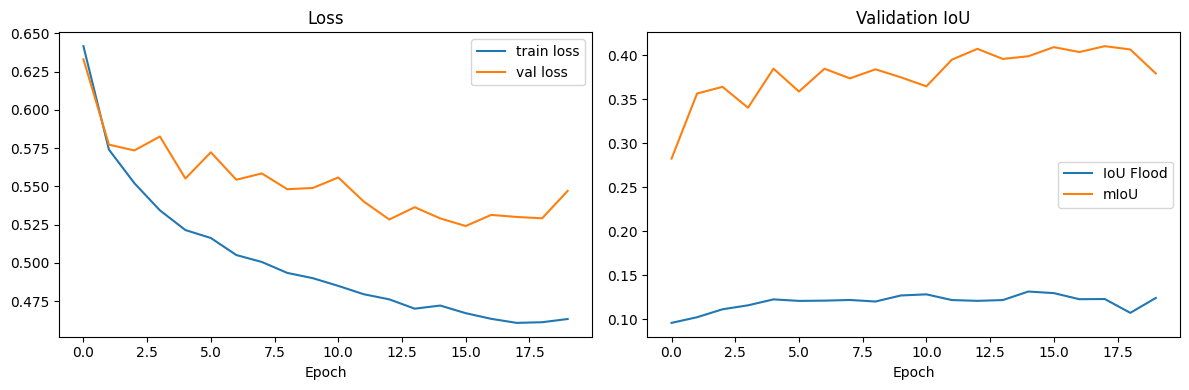

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train loss')
axes[0].plot(history['val_loss'],   label='val loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['val_iou_flood'], label='IoU Flood')
axes[1].plot(history['val_miou'],      label='mIoU')
axes[1].set_title('Validation IoU'); axes[1].legend(); axes[1].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(str(CFG['VIZ_DIR'] / 'training_curves.png'), dpi=150)
plt.show()


## 13 · Load Best Checkpoint

In [16]:
print(f'Loading best checkpoint from {CKPT_PATH} …')
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Loaded  epoch {ckpt["epoch"]}  '
      f'(Flood IoU = {ckpt["best_flood_iou"]:.4f}) ✓')


Loading best checkpoint from /kaggle/working/checkpoints/best_yolo_flood_iou.pt …
Loaded  epoch 15  (Flood IoU = 0.1315) ✓


In [24]:
!zip ckpt.zip /kaggle/working/checkpoints/best_yolo_flood_iou.pt



  adding: kaggle/working/checkpoints/best_yolo_flood_iou.pt (deflated 28%)


## 14 · Full-Image Inference & Dynamic Threshold

In [17]:
@torch.no_grad()
def predict_full_image(img_path, model, patch_size, stride):
    """Returns (FULL_SIZE, FULL_SIZE, NUM_CLASSES) softmax probabilities."""
    img   = normalise(load_tif(img_path), CH_MEAN, CH_STD, CH_P1, CH_P99)
    ptchs = extract_patches(img, patch_size, stride)

    soft_patches = []
    for p_img, r, c in ptchs:
        t = torch.from_numpy(p_img.transpose(2,0,1)).unsqueeze(0).to(DEVICE)
        with autocast(enabled=CFG['AMP']):
            logit = model(t)   # (1, C, H', W')
        # resize logits back to patch_size before stitching
        logit = F.interpolate(logit.float(), size=(patch_size, patch_size),
                              mode='bilinear', align_corners=False)
        soft = torch.softmax(logit, dim=1).squeeze(0)   # (C, P, P)
        soft_patches.append((soft.cpu().numpy().transpose(1,2,0), r, c))

    return stitch_patches(soft_patches,
                          full_size=CFG['FULL_SIZE'],
                          patch_size=patch_size,
                          n_classes=NUM_CLASSES)


def apply_threshold(soft, flood_thresh=0.5):
    pred = np.argmax(soft, axis=-1).astype(np.uint8)
    flood_mask = soft[..., 1] >= flood_thresh
    pred[flood_mask] = 1
    no_flood = (~flood_mask) & (pred == 1)
    alt = np.argmax(soft[..., [0, 2]], axis=-1)
    pred[no_flood] = np.where(alt == 0, 0, 2)[no_flood]
    return pred


def iou_class(pred, gt, cls):
    tp = np.sum((pred == cls) & (gt == cls))
    fp = np.sum((pred == cls) & (gt != cls))
    fn = np.sum((pred != cls) & (gt == cls))
    return tp / (tp + fp + fn + 1e-6)


# ── Collect val predictions for threshold search ────────────────────────────
print('Predicting on test set (GT available) for threshold tuning …')
val_softs, val_gts = [], []
for sid in test_ids:
    ip = CFG['IMAGE_DIR'] / f'{sid}_image.tif'
    lp = CFG['LABEL_DIR'] / f'{sid}_label.tif'
    if not ip.exists() or not lp.exists():
        continue
    val_softs.append(predict_full_image(ip, model, CFG['PATCH_SIZE'], CFG['STRIDE']))
    val_gts.append(load_label(lp))
    print(f'  {sid} done')

thresholds = np.linspace(0.0, 1.0, CFG['THRESH_STEPS'])
best_thresh, best_tiou = 0.5, -1.0
for t in thresholds:
    ious   = [iou_class(apply_threshold(s, t), g, 1) for s, g in zip(val_softs, val_gts)]
    miou_t = float(np.mean(ious))
    if miou_t > best_tiou:
        best_tiou, best_thresh = miou_t, t

print(f'\nBest flood threshold: {best_thresh:.2f}  (Flood IoU = {best_tiou:.4f})')


Predicting on test set (GT available) for threshold tuning …
  20240529_EO4_RES2_fl_pid_070 done
  20240529_EO4_RES2_fl_pid_071 done
  20240529_EO4_RES2_fl_pid_072 done
  20240529_EO4_RES2_fl_pid_073 done
  20240529_EO4_RES2_fl_pid_074 done
  20240529_EO4_RES2_fl_pid_075 done
  20240529_EO4_RES2_fl_pid_076 done
  20240529_EO4_RES2_fl_pid_077 done
  20240529_EO4_RES2_fl_pid_078 done
  20240529_EO4_RES2_fl_pid_079 done

Best flood threshold: 0.40  (Flood IoU = 0.1340)


## 15 · Validation Visualisations

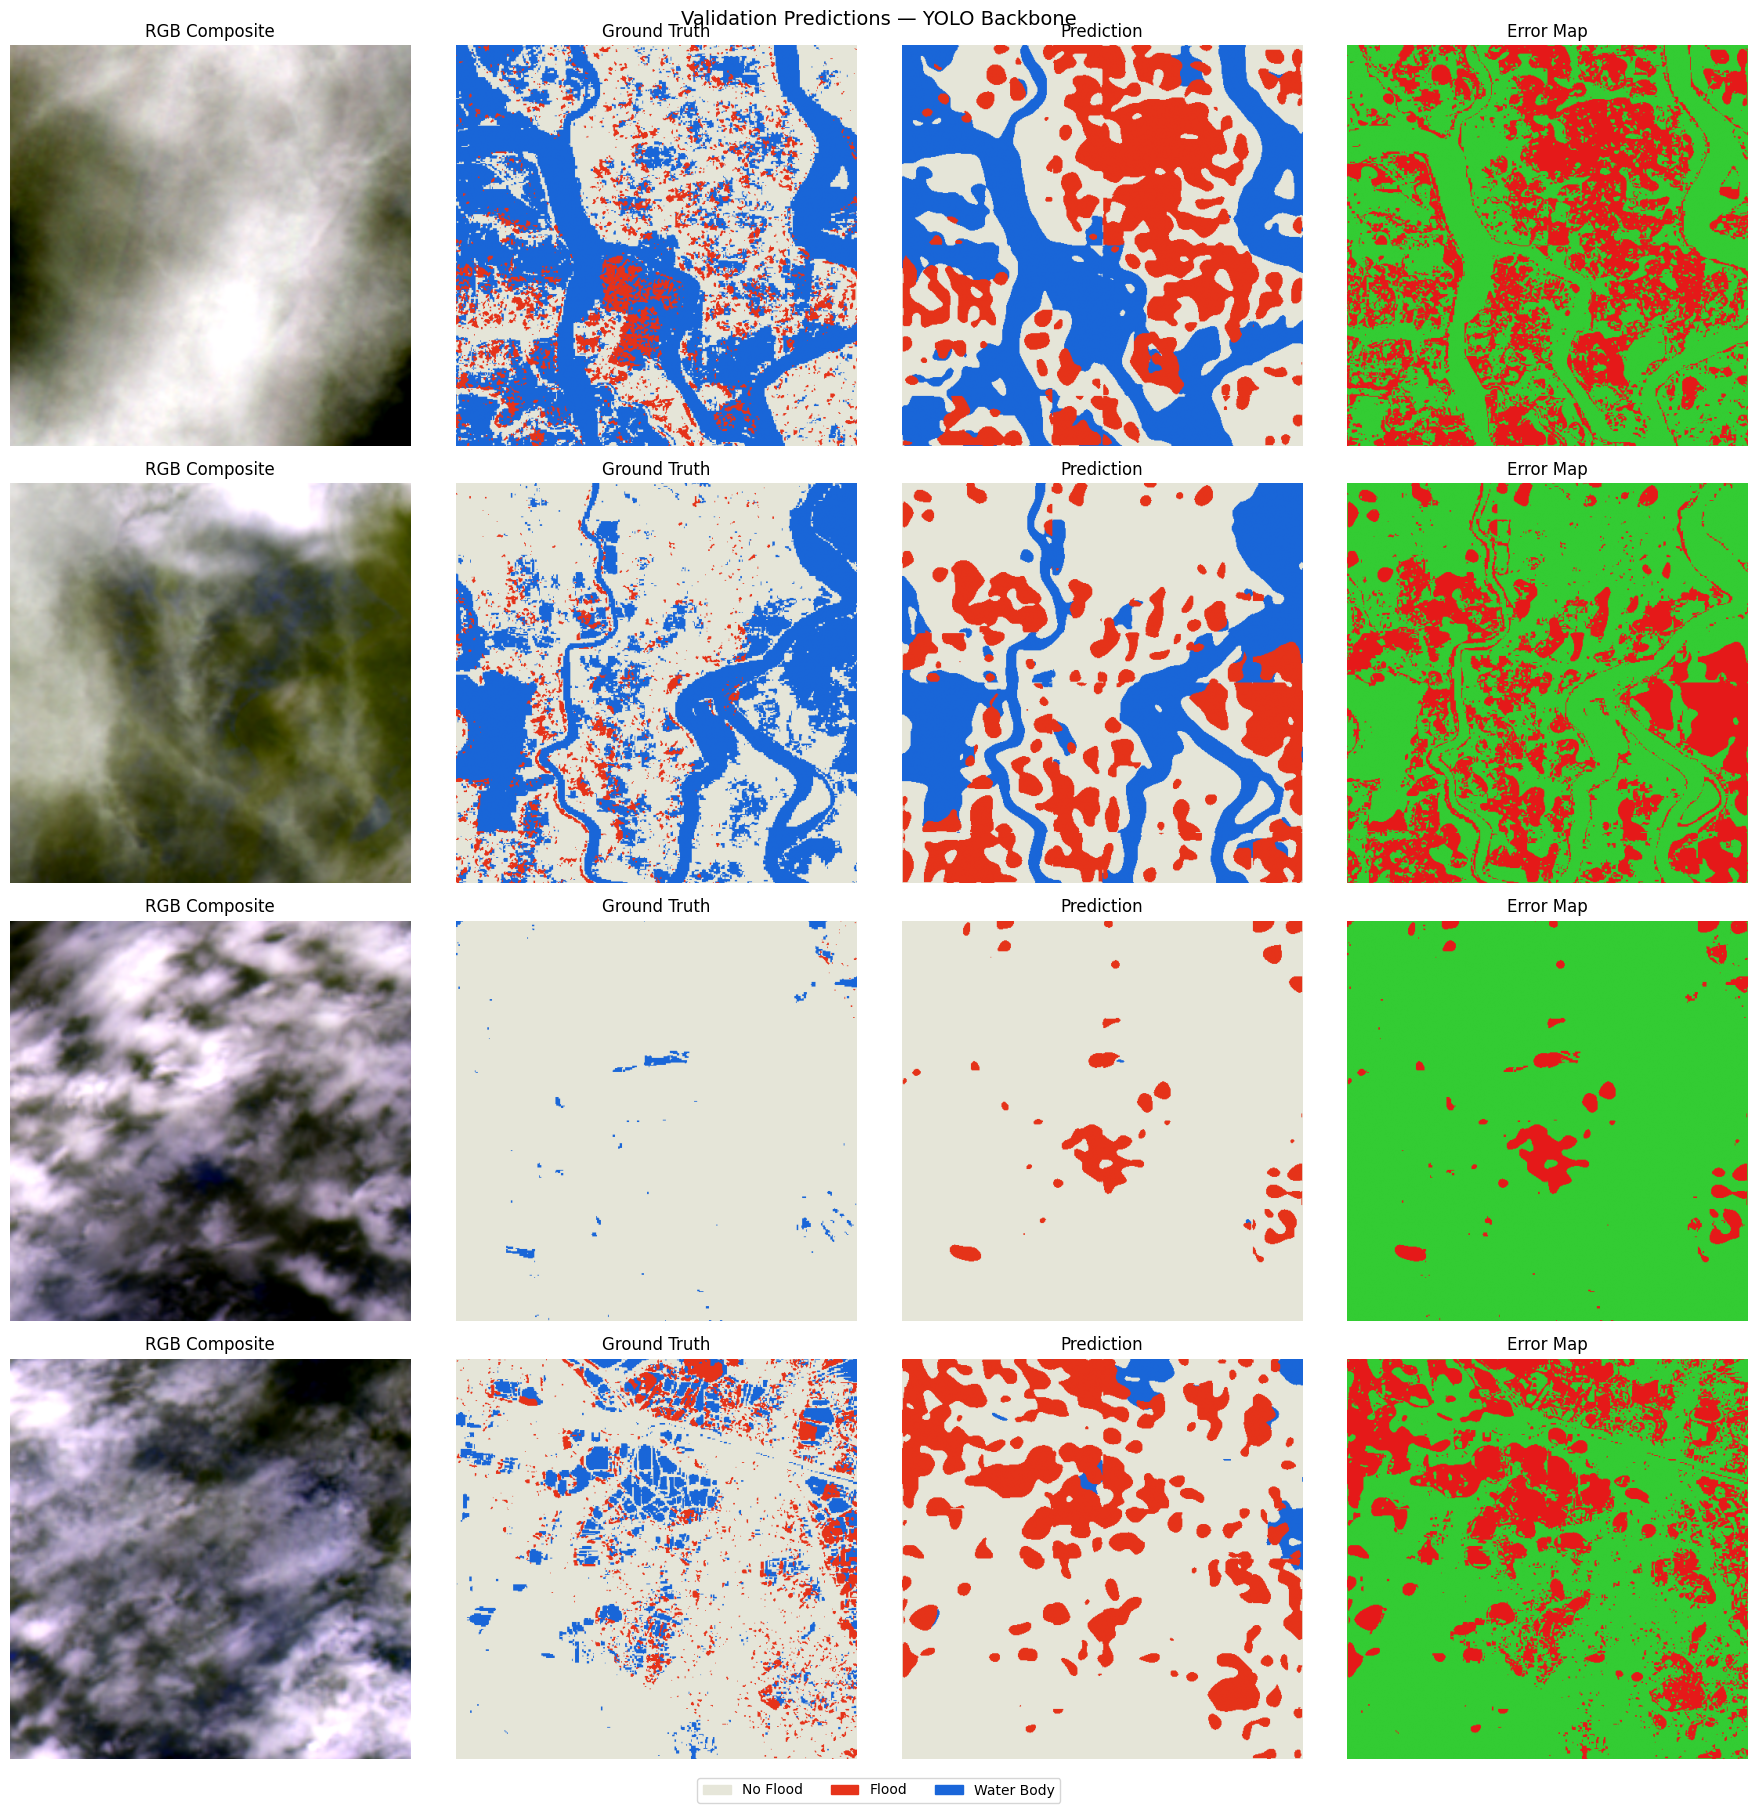

Visualisations saved ✓


In [18]:
CMAP   = {0: [0.9, 0.9, 0.85], 1: [0.9, 0.2, 0.1], 2: [0.1, 0.4, 0.85]}
LABELS = {0: 'No Flood', 1: 'Flood', 2: 'Water Body'}


def label_to_rgb(arr):
    rgb = np.zeros((*arr.shape, 3))
    for k, c in CMAP.items():
        rgb[arr == k] = c
    return rgb


def pseudo_rgb(img_norm):
    r = img_norm[..., 3]; g = img_norm[..., 2]; b = img_norm[..., 4]
    rgb = np.stack([r, g, b], axis=-1)
    lo, hi = np.percentile(rgb, [2, 98])
    return np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)


n_vis = min(4, len(test_ids))
fig, axes = plt.subplots(n_vis, 4, figsize=(18, 4.5*n_vis))
if n_vis == 1:
    axes = axes[np.newaxis, :]

for i, (sid, soft, gt) in enumerate(
        zip(test_ids[:n_vis], val_softs[:n_vis], val_gts[:n_vis])):
    img_raw = normalise(load_tif(CFG['IMAGE_DIR'] / f'{sid}_image.tif'),
                        CH_MEAN, CH_STD, CH_P1, CH_P99)
    pred = apply_threshold(soft, best_thresh)

    axes[i,0].imshow(pseudo_rgb(img_raw));   axes[i,0].set_title('RGB Composite')
    axes[i,1].imshow(label_to_rgb(gt));      axes[i,1].set_title('Ground Truth')
    axes[i,2].imshow(label_to_rgb(pred));    axes[i,2].set_title('Prediction')

    err = np.zeros((*gt.shape, 3))
    err[pred==gt] = [0.2, 0.8, 0.2]
    err[pred!=gt] = [0.9, 0.1, 0.1]
    axes[i,3].imshow(err);                   axes[i,3].set_title('Error Map')
    axes[i,0].set_ylabel(f'{sid}\nFlood IoU={iou_class(pred,gt,1):.3f}', fontsize=8)
    for ax in axes[i]: ax.axis('off')

leg = [mpatches.Patch(color=CMAP[k], label=LABELS[k]) for k in CMAP]
fig.legend(handles=leg, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Validation Predictions — YOLO Backbone', fontsize=14)
plt.tight_layout()
fig.savefig(str(CFG['VIZ_DIR'] / 'val_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Visualisations saved ✓')


## 16 · Test Set Metrics

In [19]:
test_results = []
for sid in test_ids:
    ip = CFG['IMAGE_DIR'] / f'{sid}_image.tif'
    lp = CFG['LABEL_DIR'] / f'{sid}_label.tif'
    if not ip.exists():
        ip = CFG['PRED_IMAGE_DIR'] / f'{sid}_image.tif'
    if not ip.exists():
        continue
    soft = predict_full_image(ip, model, CFG['PATCH_SIZE'], CFG['STRIDE'])
    pred = apply_threshold(soft, best_thresh)
    row  = {'id': sid}
    if lp.exists():
        gt = load_label(lp)
        for cls, name in enumerate(['NoFlood','Flood','WaterBody']):
            row[f'IoU_{name}'] = iou_class(pred, gt, cls)
        row['mIoU'] = np.mean([row[f'IoU_{n}'] for n in ['NoFlood','Flood','WaterBody']])
        row['acc']  = float(np.mean(pred == gt))
    test_results.append(row)

df_test = pd.DataFrame(test_results)
print(df_test.to_string())
if 'mIoU' in df_test.columns:
    print('\n── Aggregate ──')
    print(df_test[['IoU_NoFlood','IoU_Flood','IoU_WaterBody','mIoU','acc']].mean())


                             id  IoU_NoFlood  IoU_Flood  IoU_WaterBody      mIoU       acc
0  20240529_EO4_RES2_fl_pid_070     0.500025   0.158577       0.576460  0.411688  0.613319
1  20240529_EO4_RES2_fl_pid_071     0.669520   0.085222       0.537282  0.430675  0.682358
2  20240529_EO4_RES2_fl_pid_072     0.958745   0.006071       0.016225  0.327014  0.953518
3  20240529_EO4_RES2_fl_pid_073     0.757213   0.129841       0.072890  0.319981  0.705677
4  20240529_EO4_RES2_fl_pid_074     0.788178   0.178069       0.114649  0.360299  0.767071
5  20240529_EO4_RES2_fl_pid_075     0.751980   0.185736       0.092893  0.343537  0.709209
6  20240529_EO4_RES2_fl_pid_076     0.607400   0.266348       0.430525  0.434758  0.607533
7  20240529_EO4_RES2_fl_pid_077     0.477358   0.140569       0.604531  0.407486  0.637379
8  20240529_EO4_RES2_fl_pid_078     0.604629   0.147538       0.660141  0.470769  0.708309
9  20240529_EO4_RES2_fl_pid_079     0.712193   0.041914       0.595872  0.449993  0.743427

## 17 · RLE Encoding & Submission CSV

In [20]:
def mask_to_rle(mask_2d, target_class=1):
    binary = (mask_2d == target_class).astype(np.uint8)
    flat   = binary.flatten(order='F')
    if flat.sum() == 0:
        return '0 0'
    padded  = np.concatenate([[0], flat, [0]])
    diff    = np.diff(padded.astype(np.int8))
    starts  = np.where(diff ==  1)[0] + 1
    ends    = np.where(diff == -1)[0] + 1
    return ' '.join(f'{s} {l}' for s, l in zip(starts, ends - starts))


def generate_submission(pred_ids, model, patch_size, stride, thresh,
                        pred_img_dir, img_dir, out_csv):
    rows = []
    for sid in pred_ids:
        ip = pred_img_dir / f'{sid}_image.tif'
        if not ip.exists():
            ip = img_dir / f'{sid}_image.tif'
        if not ip.exists():
            rows.append({'id': sid, 'rle_mask': '0 0'}); continue
        soft = predict_full_image(ip, model, patch_size, stride)
        pred = apply_threshold(soft, thresh)
        rle  = mask_to_rle(pred)
        rows.append({'id': sid, 'rle_mask': rle})
        print(f'  {sid}: {rle[:60]} …')
    df = pd.DataFrame(rows, columns=['id', 'rle_mask'])
    df.to_csv(out_csv, index=False)
    print(f'\nSubmission saved → {out_csv}  ({len(df)} rows)')
    return df


print('Generating submission …')
df_sub = generate_submission(
    pred_ids, model,
    CFG['PATCH_SIZE'], CFG['STRIDE'], best_thresh,
    CFG['PRED_IMAGE_DIR'], CFG['IMAGE_DIR'], CFG['SUB_CSV'])
df_sub.head(10)


Generating submission …
  20240529_EO4_RES2_fl_pid_080: 1003 21 1482 8 1514 22 1992 13 2026 21 2502 16 2538 19 3014  …
  20240529_EO4_RES2_fl_pid_081: 270 8 291 12 341 17 424 22 447 1 449 1 777 41 850 24 933 34  …
  20240529_EO4_RES2_fl_pid_082: 474 4 661 17 717 10 736 29 979 17 1011 14 1172 19 1227 14 12 …
  20240529_EO4_RES2_fl_pid_083: 400 5 516 26 567 29 687 18 720 19 775 25 814 3 879 4 907 20  …
  20240529_EO4_RES2_fl_pid_084: 347 17 745 23 789 32 848 31 889 12 1256 24 1300 35 1360 32 1 …
  20240529_EO4_RES2_fl_pid_085: 260 5 282 10 308 18 344 9 435 8 449 59 749 63 814 83 902 123 …
  20240529_EO4_RES2_fl_pid_086: 519 25 552 23 993 15 1029 29 1062 26 1504 16 1540 29 1575 27 …
  20240529_EO4_RES2_fl_pid_087: 26850 3 27360 7 27871 9 28383 10 28895 10 29407 11 29919 11  …
  20240529_EO4_RES2_fl_pid_088: 10073 6 10583 10 11094 12 11605 13 12117 13 12629 13 13050 7 …
  20240529_EO4_RES2_fl_pid_089: 5119 1 5627 5 6137 8 6647 10 7158 11 7669 12 8181 12 8692 13 …
  20240529_EO4_RES2_fl_pid

,id,rle_mask
0,20240529_EO4_RES2_fl_pid_080,1003 21 1482 8 1514 22 1992 13 2026 21 2502 16...
1,20240529_EO4_RES2_fl_pid_081,270 8 291 12 341 17 424 22 447 1 449 1 777 41 ...
2,20240529_EO4_RES2_fl_pid_082,474 4 661 17 717 10 736 29 979 17 1011 14 1172...
3,20240529_EO4_RES2_fl_pid_083,400 5 516 26 567 29 687 18 720 19 775 25 814 3...
4,20240529_EO4_RES2_fl_pid_084,347 17 745 23 789 32 848 31 889 12 1256 24 130...
5,20240529_EO4_RES2_fl_pid_085,260 5 282 10 308 18 344 9 435 8 449 59 749 63 ...
6,20240529_EO4_RES2_fl_pid_086,519 25 552 23 993 15 1029 29 1062 26 1504 16 1...
7,20240529_EO4_RES2_fl_pid_087,26850 3 27360 7 27871 9 28383 10 28895 10 2940...
8,20240529_EO4_RES2_fl_pid_088,10073 6 10583 10 11094 12 11605 13 12117 13 12...
9,20240529_EO4_RES2_fl_pid_089,5119 1 5627 5 6137 8 6647 10 7158 11 7669 12 8...


## 18 · Sanity-Check RLE

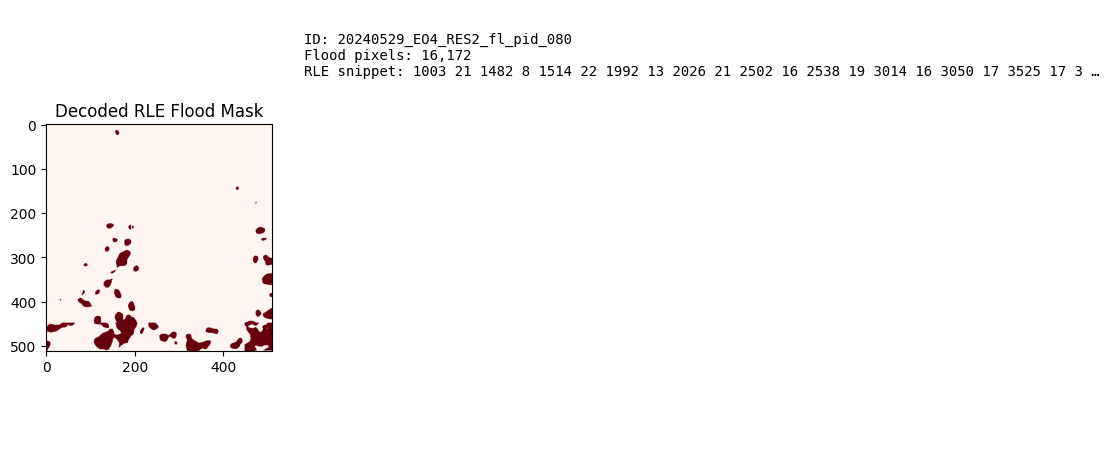

RLE sanity check complete ✓


In [21]:
def rle_to_mask(rle_str, h=512, w=512):
    mask = np.zeros(h*w, dtype=np.uint8)
    if rle_str.strip() in ('', '0 0'):
        return mask.reshape(h, w, order='F')
    nums = list(map(int, rle_str.split()))
    for s, l in zip(nums[::2], nums[1::2]):
        mask[s-1:s-1+l] = 1
    return mask.reshape(h, w, order='F')


row0    = df_sub.iloc[0]
decoded = rle_to_mask(row0['rle_mask'])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(decoded, cmap='Reds')
axes[0].set_title('Decoded RLE Flood Mask')
axes[1].axis('off')
axes[1].text(0.05, 0.95,
    f"ID: {row0['id']}\nFlood pixels: {decoded.sum():,}\n"
    f"RLE snippet: {row0['rle_mask'][:80]} …",
    va='top', fontsize=10, transform=axes[1].transAxes, family='monospace')
plt.tight_layout()
plt.savefig(str(CFG['VIZ_DIR'] / 'rle_sanity.png'), dpi=150)
plt.show()
print('RLE sanity check complete ✓')
